# 🚖 Hackathon DATA 4 CHANGE — Sosso Trajet
## Pipeline — Étapes 4 · 5 · 6 · 7 : Feature Engineering → Modélisation → Évaluation → Déploiement

---
> **Prérequis :** Exécuter d'abord `SossoTrajet_Analysis.ipynb` (Étapes 1–3).  
> Ce notebook reprend depuis le dataset brut et applique toute la chaîne jusqu'à la prédiction.

## ⚙️ Imports & Rechargement du dataset

In [53]:
# ─── Installation des librairies si nécessaire ───────────────
# !pip install xgboost scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# FIX: Un seul bloc d'imports sklearn (suppression du doublon GradientBoostingRegressor)
from sklearn.model_selection  import train_test_split, cross_val_score, KFold
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model     import LinearRegression, Ridge
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score

# Style dark
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#1e1e2e', 'axes.facecolor': '#2a2a3e',
    'axes.labelcolor': 'white',    'xtick.color': 'white',
    'ytick.color': 'white',        'text.color': 'white',
    'axes.titlecolor': 'white',    'grid.color': '#3a3a5e',
    'figure.titlesize': 14,        'axes.titlesize': 12,
})
COLORS = ['#7c3aed', '#06b6d4', '#f59e0b', '#10b981', '#ef4444']

DATASET_PATH = 'SossoTrajet_Dataset.csv'
RANDOM_STATE = 42

print('✅ Imports OK')

✅ Imports OK


In [54]:
df_raw = pd.read_csv(DATASET_PATH)
print(f'Dataset chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
print(f'Colonnes : {list(df_raw.columns)}')

Dataset chargé : 7,341 lignes × 11 colonnes
Colonnes : ['id_course', 'ville', 'depart', 'arrivee', 'duree_estimee', 'distance', 'prix_eco', 'prix_confort', 'prix_confort_plus', 'heure_plage', 'disponibilite_vehicules']


---
## 🔧 ÉTAPE 4 — Feature Engineering

**Objectif :** Transformer les données brutes en features exploitables par les modèles ML.

**Transformations :**
1. 🧹 Imputation des valeurs manquantes
2. ⏰ Parsing `heure_plage` → `heure_debut` (int)
3. 🚦 Encodage ordinal `disponibilite_vehicules`
4. 🏙️ Encodage binaire `ville`
5. 📦 Winsorisation des prix (P1–P99)
6. 📊 Log-transformation des prix
7. 🕐 Features temporelles (rush hour, nuit, segment)

In [55]:
# ════════════════════════════════════════════════════════════
# 4.1 — IMPUTATION (reprise étape 3)
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('🧹 4.1. IMPUTATION DES VALEURS MANQUANTES')
print('=' * 60)

df = df_raw.copy()
prix_cols = ['prix_eco', 'prix_confort', 'prix_confort_plus']

for col in prix_cols:
    nan_avant = df[col].isnull().sum()
    df[col] = df.groupby(['ville', 'heure_plage'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    df[col] = df[col].fillna(df[col].median())
    print(f'  {col:<25} | NaN avant: {nan_avant:>5} → après: {df[col].isnull().sum():>2} ✅')

df['duree_estimee'] = df['duree_estimee'].fillna(df['duree_estimee'].median())
print(f'  {"duree_estimee":<25} | Imputée avec médiane globale ✅')
print(f'\n  NaN totaux restants : {df.isnull().sum().sum()}')

🧹 4.1. IMPUTATION DES VALEURS MANQUANTES
  prix_eco                  | NaN avant:   112 → après:  0 ✅
  prix_confort              | NaN avant:  1126 → après:  0 ✅
  prix_confort_plus         | NaN avant:  1862 → après:  0 ✅
  duree_estimee             | Imputée avec médiane globale ✅

  NaN totaux restants : 0


In [56]:
# ════════════════════════════════════════════════════════════
# 4.2 — PARSING heure_plage → heure_debut
# FIX: cell metadata nettoyée (était marquée 'markdown' par erreur)
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('⏰ 4.2. PARSING heure_plage → heure_debut')
print('=' * 60)

df['heure_debut'] = df['heure_plage'].str.extract(r'^(\d+)h').astype(float)

# Cas 'inconnu' → NaN → médiane
n_inconnu = df['heure_debut'].isnull().sum()
df['heure_debut'] = df['heure_debut'].fillna(df['heure_debut'].median())

print(f'  heure_debut créée ✅')
print(f'  Valeurs "inconnu" imputées : {n_inconnu}')
print(f'  Plage : [{df["heure_debut"].min():.0f}h, {df["heure_debut"].max():.0f}h]')
print(df[['heure_plage', 'heure_debut']].head(3).to_string())

⏰ 4.2. PARSING heure_plage → heure_debut
  heure_debut créée ✅
  Valeurs "inconnu" imputées : 27
  Plage : [0h, 24h]
  heure_plage  heure_debut
0     13h–14h         13.0
1     13h–14h         13.0
2     13h–14h         13.0


In [57]:
# ════════════════════════════════════════════════════════════
# 4.3 — ENCODAGE ORDINAL disponibilite_vehicules
# FIX: métadonnée languageId 'markdown' supprimée → code Python
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('🚦 4.3. ENCODAGE ORDINAL disponibilite_vehicules')
print('=' * 60)

DISPO_MAP = {'gris': 1, 'rouge': 2, 'orange': 3, 'jaune': 4, 'vert': 5}
df['dispo_score'] = df['disponibilite_vehicules'].map(DISPO_MAP)

nan_dispo = df['dispo_score'].isnull().sum()
if nan_dispo > 0:
    df['dispo_score'] = df['dispo_score'].fillna(df['dispo_score'].median())
    print(f'  ⚠️  {nan_dispo} valeurs inconnues imputées avec la médiane')
print(f'  Mapping appliqué : {DISPO_MAP}')
print('  Distribution :')
print(df['dispo_score'].value_counts().sort_index().to_string())

🚦 4.3. ENCODAGE ORDINAL disponibilite_vehicules
  Mapping appliqué : {'gris': 1, 'rouge': 2, 'orange': 3, 'jaune': 4, 'vert': 5}
  Distribution :
dispo_score
1     367
2     155
3     183
4    1603
5    5033


In [58]:
# ════════════════════════════════════════════════════════════
# 4.4 — ENCODAGE ville + FEATURES TEMPORELLES
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('🏙️  4.4. ENCODAGE ville + FEATURES TEMPORELLES')
print('=' * 60)

df['ville_encode'] = (df['ville'] == 'Yaounde').astype(int)
print(f'  ville_encode : Yaounde=1, Douala=0')
print(f'  Distribution : {df["ville_encode"].value_counts().to_dict()}')

# Rush hours : 7-9h et 17-19h
df['is_rush_hour'] = df['heure_debut'].apply(
    lambda h: 1 if (7 <= h <= 9) or (17 <= h <= 19) else 0
).astype(int)

# Nuit : 22h-5h
df['is_nuit'] = df['heure_debut'].apply(
    lambda h: 1 if h >= 22 or h <= 5 else 0
).astype(int)

# Segment de la journée (0=Matin, 1=Après-midi, 2=Soir, 3=Nuit)
def segment_jour(h):
    if 6 <= h < 12:  return 0
    if 12 <= h < 17: return 1
    if 17 <= h < 22: return 2
    return 3

df['segment_jour'] = df['heure_debut'].apply(segment_jour)

print(f'  is_rush_hour : {df["is_rush_hour"].sum()} courses en heure de pointe')
print(f'  is_nuit      : {df["is_nuit"].sum()} courses de nuit')
print(f'  segment_jour : 0=Matin, 1=Apres-midi, 2=Soir, 3=Nuit')

🏙️  4.4. ENCODAGE ville + FEATURES TEMPORELLES
  ville_encode : Yaounde=1, Douala=0
  Distribution : {1: 7219, 0: 122}
  is_rush_hour : 1588 courses en heure de pointe
  is_nuit      : 1097 courses de nuit
  segment_jour : 0=Matin, 1=Apres-midi, 2=Soir, 3=Nuit


In [59]:
# ════════════════════════════════════════════════════════════
# 4.5 — WINSORISATION des prix (P1–P99)
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('📦 4.5. WINSORISATION des prix (P1 — P99)')
print('=' * 60)

for col in prix_cols + ['distance', 'duree_estimee']:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    avant_min = df[col].min(); avant_max = df[col].max()
    df[col] = df[col].clip(lower=p01, upper=p99)
    print(f'  {col:<25} | [{avant_min:.0f}, {avant_max:.0f}] → [{df[col].min():.0f}, {df[col].max():.0f}]')

📦 4.5. WINSORISATION des prix (P1 — P99)
  prix_eco                  | [2, 54450] → [400, 4600]
  prix_confort              | [2, 76800] → [500, 5250]
  prix_confort_plus         | [2, 126700] → [700, 6760]
  distance                  | [0, 4481] → [0, 21]
  duree_estimee             | [1, 277] → [3, 58]


In [60]:
# ════════════════════════════════════════════════════════════
# 4.6 — LOG-TRANSFORMATION des prix (log1p)
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('📊 4.6. LOG-TRANSFORMATION des prix (log1p)')
print('=' * 60)

for col in prix_cols:
    log_col = f'log_{col}'
    df[log_col] = np.log1p(df[col])
    skew_avant = df[col].skew()
    skew_apres = df[log_col].skew()
    print(f'  {col:<25} | Skew avant: {skew_avant:+.3f} → après log1p: {skew_apres:+.3f} ✅')

print()
print('  💡 log1p(x) = log(1+x), sécurisé si x = 0')

📊 4.6. LOG-TRANSFORMATION des prix (log1p)
  prix_eco                  | Skew avant: +1.584 → après log1p: +0.174 ✅
  prix_confort              | Skew avant: +1.565 → après log1p: +0.116 ✅
  prix_confort_plus         | Skew avant: +1.596 → après log1p: +0.192 ✅

  💡 log1p(x) = log(1+x), sécurisé si x = 0


In [61]:
# ════════════════════════════════════════════════════════════
# 4.7 — FEATURE ENRICHIE : vitesse estimée
# FIX LEAKAGE: prix_par_km et ratio_confort_eco SUPPRIMÉS des features
#   prix_par_km    = prix_eco / distance → utilise la cible → LEAKAGE
#   ratio_confort  = prix_confort / prix_eco → utilise la cible → LEAKAGE
#   vitesse_estimee = distance / duree → OK (pas la cible)
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('🗺️  4.7. FEATURE ENRICHIE (sans leakage)')
print('=' * 60)

# Vitesse estimée km/h — calculée SANS utiliser les prix
df['vitesse_estimee'] = (
    df['distance'] / (df['duree_estimee'] / 60 + 0.01)
).round(1)

# Identifiant de trajet (pour analyse uniquement, pas feature du modèle)
df['trajet_id'] = df['depart'].str.strip() + ' -> ' + df['arrivee'].str.strip()

print(f'  vitesse_estimee : médiane = {df["vitesse_estimee"].median():.1f} km/h')
print(f'  trajet_id       : {df["trajet_id"].nunique()} trajets uniques')
print()
print('  ⚠️  CORRECTION : prix_par_km et ratio_confort_eco EXCLUS des features')
print('  ➤  Ces features utilisaient prix_eco (cible) → Feature Leakage → RMSE artificiellement bon')

🗺️  4.7. FEATURE ENRICHIE (sans leakage)
  vitesse_estimee : médiane = 18.1 km/h
  trajet_id       : 5791 trajets uniques

  ⚠️  CORRECTION : prix_par_km et ratio_confort_eco EXCLUS des features
  ➤  Ces features utilisaient prix_eco (cible) → Feature Leakage → RMSE artificiellement bon


In [62]:
# ════════════════════════════════════════════════════════════
# 4.8 — FEATURES FINALES (corrigées, sans leakage)
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('📋 4.8. FEATURES FINALES POUR LE MODELE')
print('=' * 60)

# FIX: prix_par_km et ratio_confort_eco retirés → plus de leakage
FEATURES = [
    'distance',        # Distance du trajet (km)
    'duree_estimee',   # Durée estimée (minutes)
    'heure_debut',     # Heure de départ (0-23)
    'is_rush_hour',    # 1 si heure de pointe
    'is_nuit',         # 1 si course de nuit
    'segment_jour',    # 0=Matin, 1=AM, 2=Soir, 3=Nuit
    'dispo_score',     # Disponibilité ordinale (1-5)
    'ville_encode',    # Yaounde=1, Douala=0
    'vitesse_estimee', # Vitesse estimée km/h (sans prix)
]
TARGETS = ['prix_eco', 'log_prix_eco']

print(f'\n  Features retenues ({len(FEATURES)}) :')
for f in FEATURES:
    nan_count = df[f].isnull().sum()
    flag = '✅' if nan_count == 0 else f'⚠️  {nan_count} NaN'
    print(f'    • {f:<20} [{df[f].dtype}]  {flag}')

print(f'\n  Cibles : {TARGETS}')
print(f'  Shape dataset enrichi : {df.shape}')

📋 4.8. FEATURES FINALES POUR LE MODELE

  Features retenues (9) :
    • distance             [float64]  ✅
    • duree_estimee        [float64]  ✅
    • heure_debut          [float64]  ✅
    • is_rush_hour         [int64]  ✅
    • is_nuit              [int64]  ✅
    • segment_jour         [int64]  ✅
    • dispo_score          [int64]  ✅
    • ville_encode         [int64]  ✅
    • vitesse_estimee      [float64]  ✅

  Cibles : ['prix_eco', 'log_prix_eco']
  Shape dataset enrichi : (7341, 22)


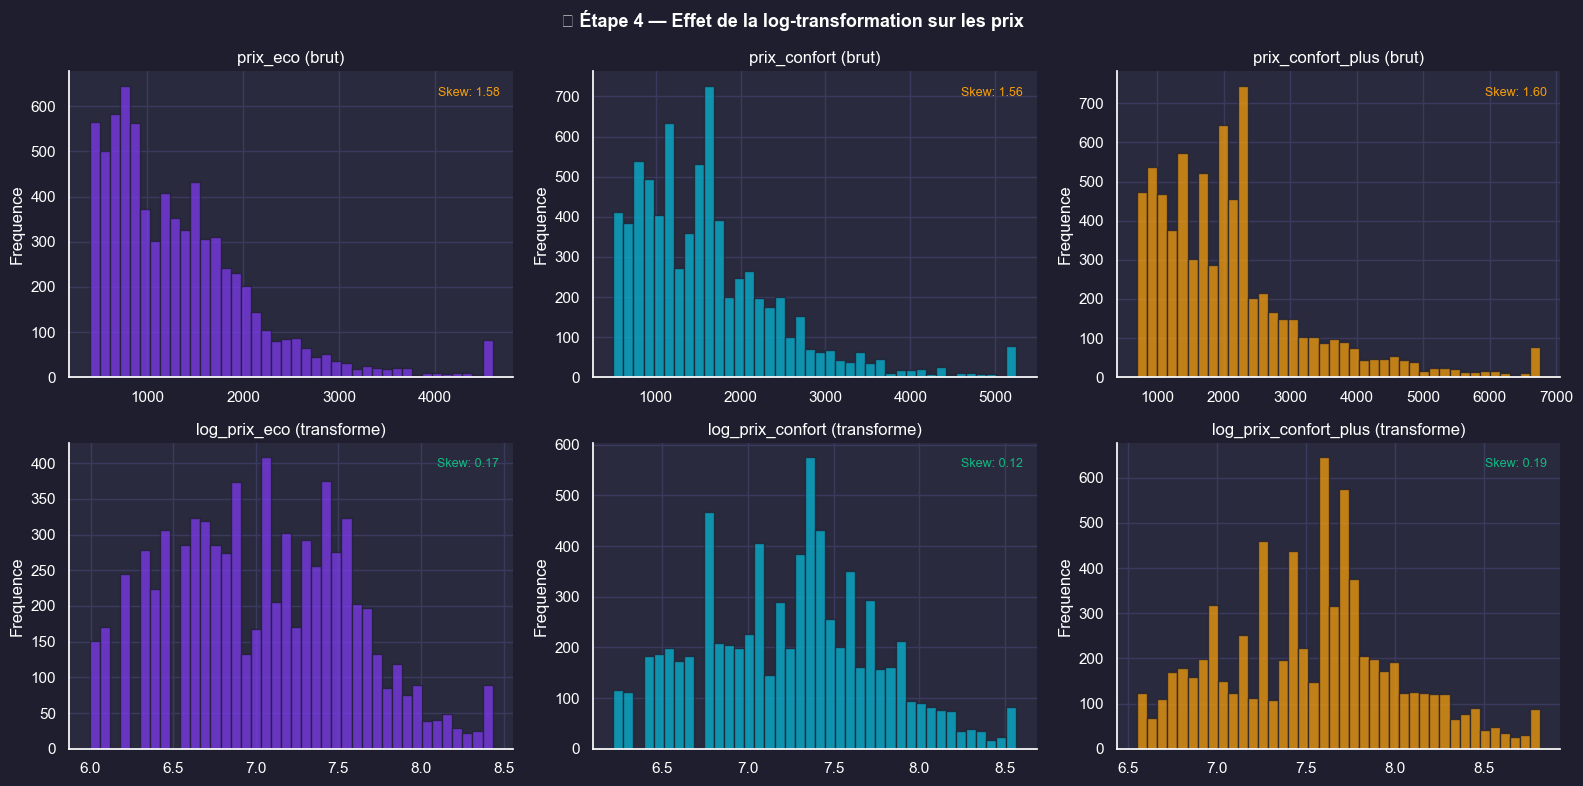

✅ Feature Engineering termine. Dataset pret pour la modelisation.


In [63]:
# ════════════════════════════════════════════════════════════
# VIZ 4 — Comparaison avant/après log-transformation
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(16, 8), facecolor='#1e1e2e')
fig.suptitle('📊 Étape 4 — Effet de la log-transformation sur les prix',
             fontsize=13, color='white', fontweight='bold')

for i, col in enumerate(prix_cols):
    ax_raw = axes[0, i]
    ax_log = axes[1, i]
    color  = COLORS[i]

    ax_raw.hist(df[col], bins=40, color=color, alpha=0.75, edgecolor='#1e1e2e')
    ax_raw.set_title(f'{col} (brut)', color='white')
    ax_raw.set_facecolor('#2a2a3e')
    ax_raw.spines[['top', 'right']].set_visible(False)
    ax_raw.set_ylabel('Frequence')
    ax_raw.text(0.97, 0.95, f'Skew: {df[col].skew():.2f}',
                transform=ax_raw.transAxes, ha='right', va='top',
                color='#f59e0b', fontsize=9)

    log_col = f'log_{col}'
    ax_log.hist(df[log_col], bins=40, color=color, alpha=0.75, edgecolor='#1e1e2e')
    ax_log.set_title(f'{log_col} (transforme)', color='white')
    ax_log.set_facecolor('#2a2a3e')
    ax_log.spines[['top', 'right']].set_visible(False)
    ax_log.set_ylabel('Frequence')
    ax_log.text(0.97, 0.95, f'Skew: {df[log_col].skew():.2f}',
                transform=ax_log.transAxes, ha='right', va='top',
                color='#10b981', fontsize=9)

plt.tight_layout()
plt.savefig('viz_log_transform.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('✅ Feature Engineering termine. Dataset pret pour la modelisation.')

### 📝 Résumé Étape 4

| Feature | Type | Rôle |
|---|---|---|
| `distance` | float | Distance du trajet |
| `duree_estimee` | float | Durée prévue |
| `heure_debut` | float (0-23) | Heure de départ |
| `is_rush_hour` | binaire | Heure de pointe |
| `is_nuit` | binaire | Course nocturne |
| `segment_jour` | ordinal (0-3) | Partie de la journée |
| `dispo_score` | ordinal (1-5) | Disponibilité véhicules |
| `ville_encode` | binaire | Yaoundé=1 / Douala=0 |
| `vitesse_estimee` | float | km/h (sans prix → pas de leakage) |

> ⚠️ **Correction appliquée :** `prix_par_km` et `ratio_confort_eco` ont été retirés car ils utilisaient `prix_eco` (la cible) comme input → **feature leakage**.

---
## 🤖 ÉTAPE 5 — Modélisation

**Stratégie :**
- Cible : `log_prix_eco` → résultat reconverti en XAF avec `expm1`
- 4 modèles comparés + XGBoost si disponible
- Validation croisée 5-fold sur le train set
- Évaluation finale en XAF réels

In [64]:
# ════════════════════════════════════════════════════════════
# 5.1 — SPLIT TRAIN / TEST (80% / 20%)
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('🔀 5.1. SPLIT TRAIN / TEST (80% / 20%)')
print('=' * 60)

X     = df[FEATURES].copy()
y     = df['log_prix_eco'].copy()  # Cible log
y_raw = df['prix_eco'].copy()      # Cible en XAF pour évaluation

# train_test_split accepte plusieurs arrays → retourne 6 valeurs
X_train, X_test, y_train, y_test, y_raw_train, y_raw_test = train_test_split(
    X, y, y_raw, test_size=0.20, random_state=RANDOM_STATE
)

print(f'  X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'  y_train : {y_train.shape}  |  y_test : {y_test.shape}')
print(f'\n  NaN dans X_train : {X_train.isnull().sum().sum()}')
print(f'  NaN dans X_test  : {X_test.isnull().sum().sum()}')

🔀 5.1. SPLIT TRAIN / TEST (80% / 20%)
  X_train : (5872, 9)  |  X_test : (1469, 9)
  y_train : (5872,)  |  y_test : (1469,)

  NaN dans X_train : 0
  NaN dans X_test  : 0


In [65]:
# ════════════════════════════════════════════════════════════
# 5.2 — DEFINITION DES MODELES
# FIX: import GradientBoostingRegressor supprimé (déjà fait en haut)
# ════════════════════════════════════════════════════════════
MODELS = {
    'Regression Lineaire' : LinearRegression(),
    'Ridge (a=10)'        : Ridge(alpha=10, random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestRegressor(
                                n_estimators=200,
                                max_depth=12,
                                min_samples_leaf=5,
                                random_state=RANDOM_STATE,
                                n_jobs=-1
                            ),
    'Gradient Boosting'   : GradientBoostingRegressor(
                                n_estimators=300,
                                learning_rate=0.05,
                                max_depth=5,
                                subsample=0.8,
                                random_state=RANDOM_STATE
                            ),
}

print('Modeles definis :')
for name in MODELS:
    print(f'  • {name}')

# XGBoost (optionnel)
try:
    from xgboost import XGBRegressor
    MODELS['XGBoost'] = XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=6, subsample=0.8,
        colsample_bytree=0.8, random_state=RANDOM_STATE,
        verbosity=0
    )
    print('  • XGBoost ✅ (disponible)')
except ImportError:
    print('  ⚠️  XGBoost absent — pip install xgboost')

Modeles definis :
  • Regression Lineaire
  • Ridge (a=10)
  • Random Forest
  • Gradient Boosting
  • XGBoost ✅ (disponible)


In [66]:
# ════════════════════════════════════════════════════════════
# 5.3 — ENTRAINEMENT + CROSS-VALIDATION (5-fold)
# FIX: n_jobs retiré de cross_val_score pour eviter conflits
#      quand le modele lui-meme utilise n_jobs=-1
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('🏋️  5.3. ENTRAINEMENT + CROSS-VALIDATION (5-fold)')
print('=' * 60)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in MODELS.items():
    # Validation croisée
    cv_rmse = cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='neg_root_mean_squared_error'
    )
    cv_r2 = cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='r2'
    )
    # Entrainement final sur tout le train
    model.fit(X_train, y_train)

    cv_results[name] = {
        'cv_rmse_mean' : -cv_rmse.mean(),
        'cv_rmse_std'  : cv_rmse.std(),
        'cv_r2_mean'   : cv_r2.mean(),
    }
    print(f'  [{name:<22}] CV RMSE: {-cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}  |  CV R2: {cv_r2.mean():.4f}')

print('\n  ✅ Tous les modeles entraines.')

🏋️  5.3. ENTRAINEMENT + CROSS-VALIDATION (5-fold)
  [Regression Lineaire   ] CV RMSE: 0.3489 ± 0.0140  |  CV R2: 0.5923
  [Ridge (a=10)          ] CV RMSE: 0.3489 ± 0.0140  |  CV R2: 0.5924
  [Random Forest         ] CV RMSE: 0.2991 ± 0.0172  |  CV R2: 0.7001
  [Gradient Boosting     ] CV RMSE: 0.2966 ± 0.0165  |  CV R2: 0.7051
  [XGBoost               ] CV RMSE: 0.2944 ± 0.0178  |  CV R2: 0.7093

  ✅ Tous les modeles entraines.


In [67]:
# ════════════════════════════════════════════════════════════
# 5.4 — EVALUATION SUR LE TEST SET (en XAF reels)
# FIX: MODELS et cv_results maintenant garantis définis (cellules précédentes)
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('📏 5.4. METRIQUES SUR LE TEST SET (en XAF reels)')
print('=' * 60)

test_results = {}

for name, model in MODELS.items():
    y_pred_log = model.predict(X_test)
    # Reconversion log → XAF : expm1(log1p(x)) = x
    y_pred_xaf = np.expm1(y_pred_log)
    y_pred_xaf = np.clip(y_pred_xaf, 0, None)  # Pas de prix negatif

    rmse = np.sqrt(mean_squared_error(y_raw_test, y_pred_xaf))
    mae  = mean_absolute_error(y_raw_test, y_pred_xaf)
    r2   = r2_score(y_raw_test, y_pred_xaf)
    mape = np.mean(np.abs((y_raw_test - y_pred_xaf) / (y_raw_test + 1))) * 100

    test_results[name] = {
        'RMSE (XAF)' : rmse,
        'MAE (XAF)'  : mae,
        'R2'         : r2,
        'MAPE (%)'   : mape,
        'y_pred'     : y_pred_xaf
    }
    print(f'  [{name:<22}] RMSE: {rmse:>8.1f} XAF | MAE: {mae:>7.1f} XAF | R2: {r2:.4f} | MAPE: {mape:.2f}%')

# Meilleur modele (RMSE minimal)
best_model_name = min(test_results, key=lambda k: test_results[k]['RMSE (XAF)'])
best_model      = MODELS[best_model_name]
print(f'\n  🏆 Meilleur modele (RMSE) : {best_model_name}')

📏 5.4. METRIQUES SUR LE TEST SET (en XAF reels)
  [Regression Lineaire   ] RMSE:    551.2 XAF | MAE:   332.7 XAF | R2: 0.5098 | MAPE: 24.96%
  [Ridge (a=10)          ] RMSE:    551.3 XAF | MAE:   332.7 XAF | R2: 0.5097 | MAPE: 24.96%
  [Random Forest         ] RMSE:    474.6 XAF | MAE:   262.6 XAF | R2: 0.6366 | MAPE: 19.38%
  [Gradient Boosting     ] RMSE:    460.8 XAF | MAE:   260.8 XAF | R2: 0.6573 | MAPE: 19.38%
  [XGBoost               ] RMSE:    458.3 XAF | MAE:   255.8 XAF | R2: 0.6611 | MAPE: 18.98%

  🏆 Meilleur modele (RMSE) : XGBoost


---
## 📈 ÉTAPE 6 — Évaluation & Interprétabilité

**Objectif :** Comprendre les performances, visualiser les erreurs et identifier les variables les plus importantes.

In [68]:
# ════════════════════════════════════════════════════════════
# 6.1 — TABLEAU DE COMPARAISON DES MODELES
# FIX: best_model_name maintenant toujours défini (cell 5.4 exécutée avant)
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('📊 6.1. TABLEAU DE COMPARAISON DES MODELES')
print('=' * 60)

comparison = pd.DataFrame({
    name: {
        'RMSE (XAF)' : f"{v['RMSE (XAF)']:.1f}",
        'MAE (XAF)'  : f"{v['MAE (XAF)']:.1f}",
        'R2'         : f"{v['R2']:.4f}",
        'MAPE (%)'   : f"{v['MAPE (%)']:.2f}",
        'CV RMSE'    : f"{cv_results[name]['cv_rmse_mean']:.4f} +/- {cv_results[name]['cv_rmse_std']:.4f}",
        'CV R2'      : f"{cv_results[name]['cv_r2_mean']:.4f}",
    }
    for name, v in test_results.items()
}).T

print(comparison.to_string())
print(f'\n  🏆 Meilleur modele : {best_model_name}')

📊 6.1. TABLEAU DE COMPARAISON DES MODELES
                    RMSE (XAF) MAE (XAF)      R2 MAPE (%)            CV RMSE   CV R2
Regression Lineaire      551.2     332.7  0.5098    24.96  0.3489 +/- 0.0140  0.5923
Ridge (a=10)             551.3     332.7  0.5097    24.96  0.3489 +/- 0.0140  0.5924
Random Forest            474.6     262.6  0.6366    19.38  0.2991 +/- 0.0172  0.7001
Gradient Boosting        460.8     260.8  0.6573    19.38  0.2966 +/- 0.0165  0.7051
XGBoost                  458.3     255.8  0.6611    18.98  0.2944 +/- 0.0178  0.7093

  🏆 Meilleur modele : XGBoost


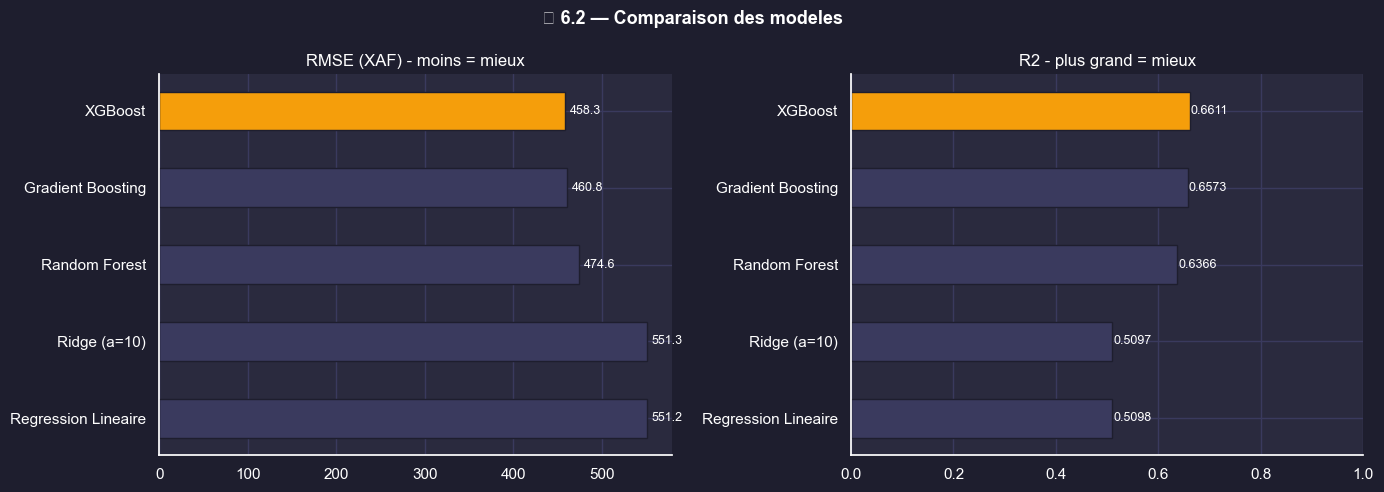

In [69]:
# ════════════════════════════════════════════════════════════
# VIZ 6.2 — Comparaison graphique RMSE & R2
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#1e1e2e')
fig.suptitle('🏆 6.2 — Comparaison des modeles',
             fontsize=13, color='white', fontweight='bold')

names      = list(test_results.keys())
rmses      = [v['RMSE (XAF)'] for v in test_results.values()]
r2s        = [v['R2']         for v in test_results.values()]
bar_colors = [COLORS[2] if n == best_model_name else '#3a3a5e' for n in names]

# RMSE
ax = axes[0]
bars = ax.barh(names, rmses, color=bar_colors, edgecolor='#1e1e2e', height=0.5)
for bar, val in zip(bars, rmses):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', color='white', fontsize=9)
ax.set_title('RMSE (XAF) - moins = mieux', color='white')
ax.set_facecolor('#2a2a3e')
ax.spines[['top', 'right']].set_visible(False)

# R2
ax2 = axes[1]
bars2 = ax2.barh(names, r2s, color=bar_colors, edgecolor='#1e1e2e', height=0.5)
for bar, val in zip(bars2, r2s):
    ax2.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', color='white', fontsize=9)
ax2.set_title('R2 - plus grand = mieux', color='white')
ax2.set_facecolor('#2a2a3e')
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('viz_comparaison_modeles.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

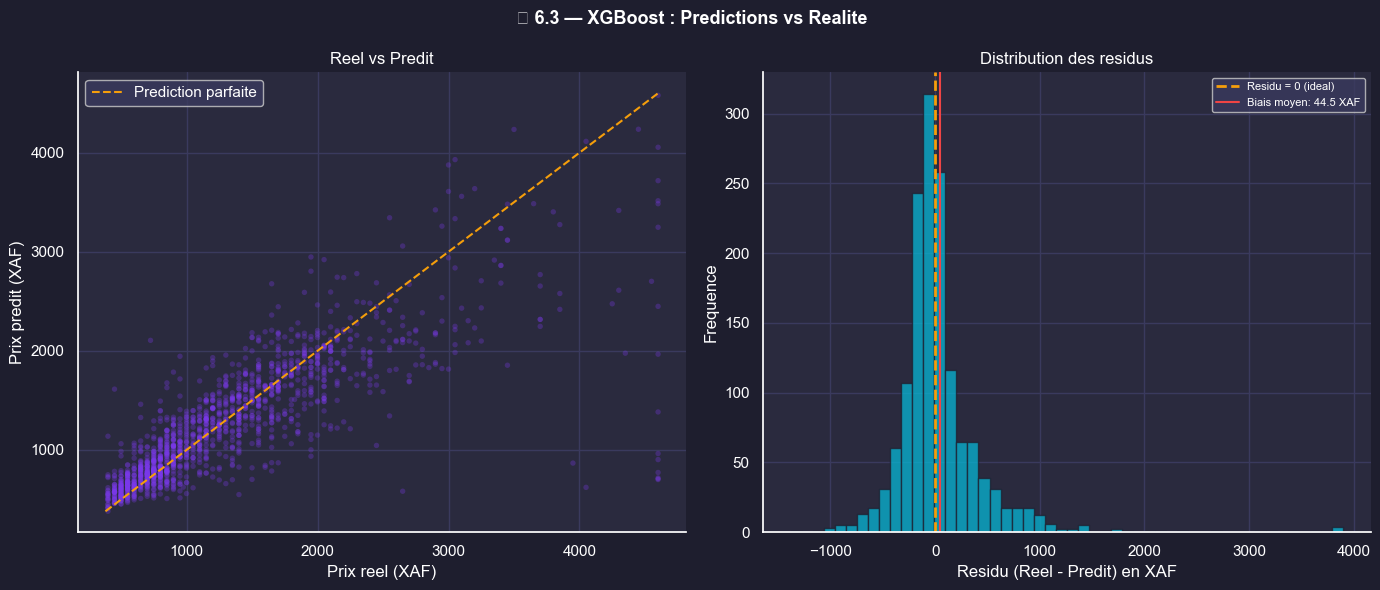

  Biais moyen : 44.5 XAF
  Std residus : 456.1 XAF


In [70]:
# ════════════════════════════════════════════════════════════
# VIZ 6.3 — Predictions vs Realite + Residus
# ════════════════════════════════════════════════════════════
y_pred_best = test_results[best_model_name]['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#1e1e2e')
fig.suptitle(f'📍 6.3 — {best_model_name} : Predictions vs Realite',
             fontsize=13, color='white', fontweight='bold')

# Scatter
ax = axes[0]
ax.scatter(y_raw_test, y_pred_best, alpha=0.3, s=15,
           color='#7c3aed', edgecolors='none')
lim_min = float(min(y_raw_test.min(), y_pred_best.min()))
lim_max = float(max(y_raw_test.max(), y_pred_best.max()))
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color='#f59e0b', lw=1.5, ls='--', label='Prediction parfaite')
ax.set_xlabel('Prix reel (XAF)')
ax.set_ylabel('Prix predit (XAF)')
ax.set_title('Reel vs Predit', color='white')
ax.legend(facecolor='#3a3a5e', labelcolor='white')
ax.set_facecolor('#2a2a3e')
ax.spines[['top', 'right']].set_visible(False)

# Residus
ax2 = axes[1]
residus = y_raw_test.values - y_pred_best
ax2.hist(residus, bins=50, color='#06b6d4', alpha=0.75, edgecolor='#1e1e2e')
ax2.axvline(0,             color='#f59e0b', lw=2,   ls='--', label='Residu = 0 (ideal)')
ax2.axvline(residus.mean(), color='#ef4444', lw=1.5, ls='-',
            label=f'Biais moyen: {residus.mean():.1f} XAF')
ax2.set_xlabel('Residu (Reel - Predit) en XAF')
ax2.set_ylabel('Frequence')
ax2.set_title('Distribution des residus', color='white')
ax2.legend(facecolor='#3a3a5e', labelcolor='white', fontsize=8)
ax2.set_facecolor('#2a2a3e')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz_residus.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

print(f'  Biais moyen : {residus.mean():.1f} XAF')
print(f'  Std residus : {residus.std():.1f} XAF')

🔑 6.4. FEATURE IMPORTANCE DU MEILLEUR MODELE


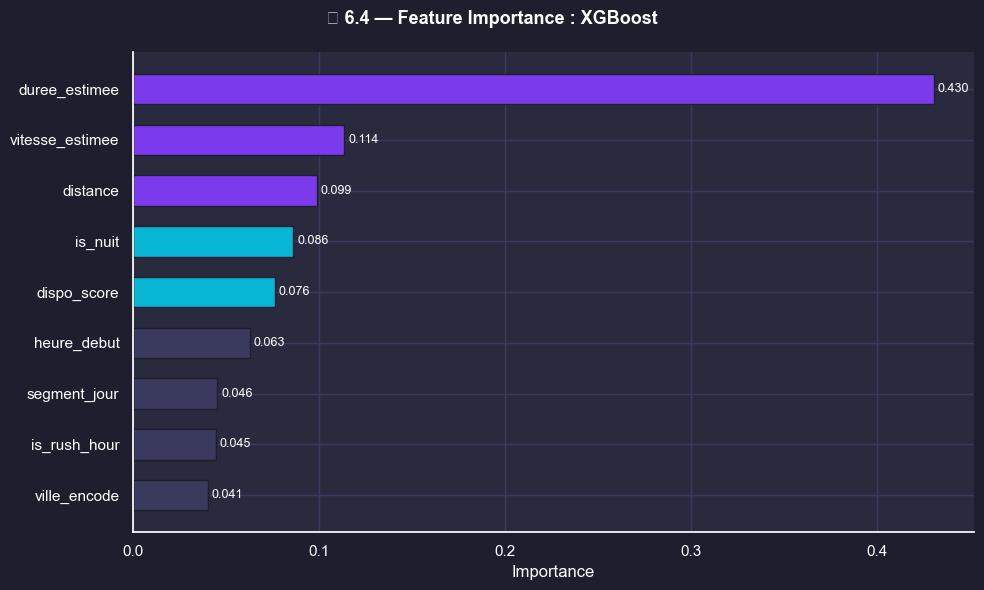


Top 5 features :
  duree_estimee          : 0.4305 (43.0%)
  vitesse_estimee        : 0.1138 (11.4%)
  distance               : 0.0990 (9.9%)
  is_nuit                : 0.0863 (8.6%)
  dispo_score            : 0.0765 (7.6%)


In [71]:
# ════════════════════════════════════════════════════════════
# VIZ 6.4 — Feature Importance
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('🔑 6.4. FEATURE IMPORTANCE DU MEILLEUR MODELE')
print('=' * 60)

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='#1e1e2e')
    fig.suptitle(f'🔑 6.4 — Feature Importance : {best_model_name}',
                 fontsize=13, color='white', fontweight='bold')

    colors_fi = ['#7c3aed' if v >= importances.quantile(0.75)
                 else '#06b6d4' if v >= importances.quantile(0.5)
                 else '#3a3a5e'
                 for v in importances.values]

    bars = ax.barh(importances.index, importances.values,
                   color=colors_fi, edgecolor='#1e1e2e', height=0.6)
    for bar, val in zip(bars, importances.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', color='white', fontsize=9)

    ax.set_xlabel('Importance')
    ax.set_facecolor('#2a2a3e')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('viz_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
    plt.show()

    print('\nTop 5 features :')
    for feat, val in importances.sort_values(ascending=False).head(5).items():
        print(f'  {feat:<22} : {val:.4f} ({val*100:.1f}%)')
else:
    print(f'  ⚠️  {best_model_name} ne supporte pas feature_importances_')
    print('  Utilisez un modele a base d\'arbres (RF, GBM, XGBoost).')

🏙️  6.5. ANALYSE DES ERREURS PAR VILLE
              N   RMSE    MAE  MAPE_pct  Prix_median
ville_nom                                           
Douala       31  745.1  423.0      18.3       2400.0
Yaounde    1438  450.1  252.2      19.0       1100.0


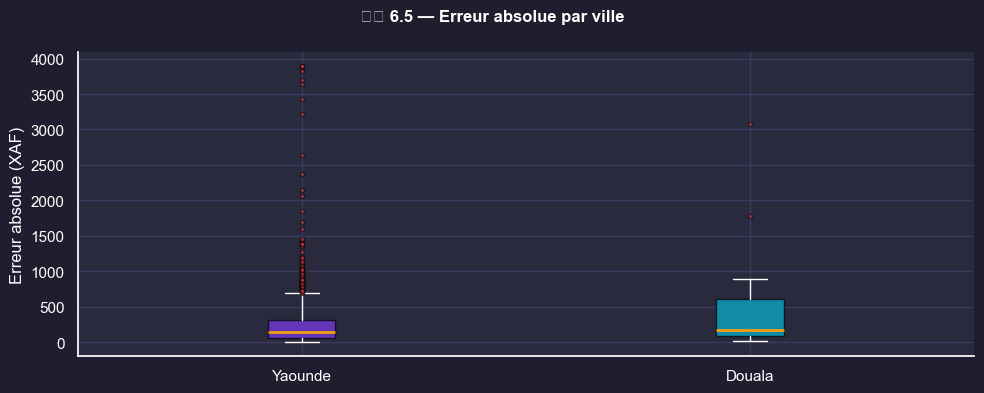

In [72]:
# ════════════════════════════════════════════════════════════
# 6.5 — ERREURS PAR VILLE
# FIX: garde-fou si une seule ville presente dans X_test
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('🏙️  6.5. ANALYSE DES ERREURS PAR VILLE')
print('=' * 60)

X_test_copy = X_test.copy()
X_test_copy['prix_reel']   = y_raw_test.values
X_test_copy['prix_predit'] = y_pred_best
X_test_copy['erreur_abs']  = np.abs(y_raw_test.values - y_pred_best)
X_test_copy['erreur_pct']  = X_test_copy['erreur_abs'] / (y_raw_test.values + 1) * 100
X_test_copy['ville_nom']   = X_test_copy['ville_encode'].map({1: 'Yaounde', 0: 'Douala'})

err_by_ville = X_test_copy.groupby('ville_nom').agg(
    N=('prix_reel', 'count'),
    RMSE=('erreur_abs', lambda x: np.sqrt((x**2).mean())),
    MAE=('erreur_abs', 'mean'),
    MAPE_pct=('erreur_pct', 'mean'),
    Prix_median=('prix_reel', 'median'),
).round(1)
print(err_by_ville.to_string())

# Boxplot (seulement si plusieurs villes)
villes_test = X_test_copy['ville_nom'].unique()
if len(villes_test) > 1:
    fig, ax = plt.subplots(figsize=(10, 4), facecolor='#1e1e2e')
    fig.suptitle('🏙️ 6.5 — Erreur absolue par ville',
                 fontsize=12, color='white', fontweight='bold')
    erreurs = [X_test_copy[X_test_copy['ville_nom'] == v]['erreur_abs'].values
               for v in villes_test]
    bp = ax.boxplot(erreurs, labels=villes_test, patch_artist=True,
                    medianprops=dict(color='#f59e0b', lw=2),
                    whiskerprops=dict(color='white'),
                    capprops=dict(color='white'),
                    flierprops=dict(markerfacecolor='#ef4444',
                                   marker='o', markersize=3, alpha=0.5))
    for patch, c in zip(bp['boxes'], COLORS):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_ylabel('Erreur absolue (XAF)')
    ax.set_facecolor('#2a2a3e')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('viz_erreur_par_ville.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
    plt.show()
else:
    print(f'  ⚠️  Une seule ville ({villes_test[0]}) dans le test set — boxplot ignore.')

In [73]:
# ════════════════════════════════════════════════════════════
# 6.6 — RESUME FINAL & RECOMMANDATIONS
# ════════════════════════════════════════════════════════════
best = test_results[best_model_name]

print('=' * 60)
print('🎯 RESULTATS FINAUX')
print('=' * 60)
print(f'  Meilleur modele : {best_model_name}')
print(f'  RMSE            : {best["RMSE (XAF)"]:.1f} XAF')
print(f'  MAE             : {best["MAE (XAF)"]:.1f} XAF')
print(f'  R2              : {best["R2"]:.4f}')
print(f'  MAPE            : {best["MAPE (%)"]:5.2f}%')
print()
print('  RECOMMANDATIONS :')
reco = [
    ('Court terme',  'Entrainer des modeles separes par ville (Yaounde / Douala)'),
    ('Court terme',  'Augmenter les donnees Douala (collecte ou augmentation)'),
    ('Moyen terme',  'Tuning hyperparametres avec Optuna ou GridSearchCV'),
    ('Moyen terme',  'Tester LightGBM (plus rapide sur CPU que XGBoost)'),
    ('Long terme',   'Modele de dispo (classification multi-classe)'),
    ('Long terme',   'Deploiement API (FastAPI + Docker)'),
]
for cat, rec in reco:
    print(f'  [{cat:<14}] {rec}')

🎯 RESULTATS FINAUX
  Meilleur modele : XGBoost
  RMSE            : 458.3 XAF
  MAE             : 255.8 XAF
  R2              : 0.6611
  MAPE            : 18.98%

  RECOMMANDATIONS :
  [Court terme   ] Entrainer des modeles separes par ville (Yaounde / Douala)
  [Court terme   ] Augmenter les donnees Douala (collecte ou augmentation)
  [Moyen terme   ] Tuning hyperparametres avec Optuna ou GridSearchCV
  [Moyen terme   ] Tester LightGBM (plus rapide sur CPU que XGBoost)
  [Long terme    ] Modele de dispo (classification multi-classe)
  [Long terme    ] Deploiement API (FastAPI + Docker)


---
## 💾 ÉTAPE 7 — Déploiement avec Joblib

**Objectif :** Sauvegarder le meilleur modèle + toute la config de préprocessing,  
pour les recharger plus tard et faire des prédictions sans réentraîner.

**Ce qu'on sauvegarde :**
- Le modèle entraîné (`.joblib`) avec compression
- La config de préprocessing (`.json`) — pour reproduire exactement les mêmes transformations

**Pourquoi Joblib et pas pickle ?**
- Joblib est plus efficace pour les objets NumPy/scikit-learn (matrices creuses, etc.)
- Il offre une compression intégrée (zlib) — fichier plus petit
- C'est le standard de facto dans l'écosystème scikit-learn

In [74]:
# ════════════════════════════════════════════════════════════
# 7.1 — IMPORT JOBLIB + DOSSIER DE SAUVEGARDE
# joblib est inclus dans scikit-learn, pas besoin d'installer séparément
# ════════════════════════════════════════════════════════════
import joblib
import json
import os
from datetime import datetime

MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

print('✅ joblib importé (inclus dans scikit-learn)')
print(f'📁 Dossier de sauvegarde : {os.path.abspath(MODEL_DIR)}')
print(f'🏆 Modèle à sauvegarder : {best_model_name}')

✅ joblib importé (inclus dans scikit-learn)
📁 Dossier de sauvegarde : c:\Users\ELITEBOOK\Desktop\DeeplearningTP\hackathon\models
🏆 Modèle à sauvegarder : XGBoost


In [75]:
# ════════════════════════════════════════════════════════════
# 7.2 — SAUVEGARDE DU MODÈLE ENTRAÎNÉ
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('💾 7.2. SAUVEGARDE DU MODELE ENTRAINE')
print('=' * 60)

# Nom de fichier avec timestamp pour traçabilité
timestamp        = datetime.now().strftime('%Y%m%d_%H%M')
model_name_clean = (
    best_model_name
    .replace(' ', '_')
    .replace('(', '').replace(')', '')
    .replace('=', '').replace('/', '')
)
MODEL_PATH = os.path.join(MODEL_DIR, f'sosso_trajet_{model_name_clean}_{timestamp}.joblib')

# Sauvegarde avec compression niveau 5 (bon équilibre vitesse / taille)
joblib.dump(best_model, MODEL_PATH, compress=5)

size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f'  Modele        : {best_model_name}')
print(f'  Fichier       : {MODEL_PATH}')
print(f'  Taille        : {size_kb:.1f} Ko')
print(f'  Compression   : niveau 5 (zlib)')
print()
print('  ✅ Modèle sauvegardé avec succès !')

💾 7.2. SAUVEGARDE DU MODELE ENTRAINE
  Modele        : XGBoost
  Fichier       : models\sosso_trajet_XGBoost_20260418_1456.joblib
  Taille        : 353.4 Ko
  Compression   : niveau 5 (zlib)

  ✅ Modèle sauvegardé avec succès !


In [76]:
# ════════════════════════════════════════════════════════════
# 7.3 — SAUVEGARDE DE LA CONFIG DE PRÉPROCESSING (JSON)
# Contient tout ce qu'il faut pour préparer de nouvelles données
# exactement comme à l'entraînement
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('🔧 7.3. SAUVEGARDE DE LA CONFIG DE PRETRAITEMENT')
print('=' * 60)

best_metrics = test_results[best_model_name]

PREPROCESSING_CONFIG = {
    # --- Identité du modèle ---
    'model_name'  : best_model_name,
    'model_path'  : MODEL_PATH,
    'saved_at'    : timestamp,

    # --- Features dans le bon ordre (CRITIQUE pour la prédiction) ---
    'features'    : FEATURES,

    # --- Cible ---
    'target'      : 'log_prix_eco',   # Ce que le modèle prédit
    'target_raw'  : 'prix_eco',        # Ce qu'on veut en sortie (reconversion expm1)

    # --- Mappings d'encodage ---
    'dispo_map'   : {'gris': 1, 'rouge': 2, 'orange': 3, 'jaune': 4, 'vert': 5},
    'ville_map'   : {'Yaounde': 1, 'Douala': 0},

    # --- Médianes pour imputer les NaN à la prédiction ---
    'medians'     : {
        col: float(df[col].median())
        for col in ['distance', 'duree_estimee', 'prix_eco', 'prix_confort', 'prix_confort_plus']
    },

    # --- Bornes de winsorisation P1/P99 (à appliquer avant log) ---
    'clip_bounds' : {
        col: {
            'p01': float(df_raw[col].quantile(0.01)),
            'p99': float(df_raw[col].quantile(0.99)),
        }
        for col in ['prix_eco', 'prix_confort', 'prix_confort_plus', 'distance', 'duree_estimee']
    },

    # --- Métriques de performance (pour comparaison future) ---
    'metrics'     : {
        'RMSE_XAF' : round(best_metrics['RMSE (XAF)'], 2),
        'MAE_XAF'  : round(best_metrics['MAE (XAF)'], 2),
        'R2'       : round(best_metrics['R2'], 6),
        'MAPE_pct' : round(best_metrics['MAPE (%)'], 4),
    },
}

CONFIG_PATH = os.path.join(MODEL_DIR, f'sosso_trajet_config_{timestamp}.json')
with open(CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(PREPROCESSING_CONFIG, f, indent=2, ensure_ascii=False)

print(f'  Config : {CONFIG_PATH}')
print(f'  Features sauvegardées ({len(FEATURES)}) : {FEATURES}')
print(f'  Métriques : RMSE={best_metrics["RMSE (XAF)"]:.1f} XAF | R2={best_metrics["R2"]:.4f}')
print()
print('  ✅ Config sauvegardée !')

🔧 7.3. SAUVEGARDE DE LA CONFIG DE PRETRAITEMENT
  Config : models\sosso_trajet_config_20260418_1456.json
  Features sauvegardées (9) : ['distance', 'duree_estimee', 'heure_debut', 'is_rush_hour', 'is_nuit', 'segment_jour', 'dispo_score', 'ville_encode', 'vitesse_estimee']
  Métriques : RMSE=458.3 XAF | R2=0.6611

  ✅ Config sauvegardée !


In [77]:
# ════════════════════════════════════════════════════════════
# 7.4 — VÉRIFICATION : rechargement + prédiction test
# On vérifie que le modèle chargé donne les mêmes résultats
# que le modèle en mémoire
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('🔁 7.4. VERIFICATION : CHARGEMENT DU MODELE')
print('=' * 60)

# Chargement du modèle depuis le disque
loaded_model = joblib.load(MODEL_PATH)

# Prédiction avec le modèle rechargé
y_pred_loaded   = np.clip(np.expm1(loaded_model.predict(X_test)), 0, None)
y_pred_original = test_results[best_model_name]['y_pred']

# Comparaison numérique
diff_max = np.abs(y_pred_loaded - y_pred_original).max()

print(f'  Modele chargé depuis          : {MODEL_PATH}')
print(f'  Diff max (original vs rechargé) : {diff_max:.2e}')

if diff_max < 0.001:
    print('  ✅ Predictions identiques — sauvegarde/chargement OK !')
else:
    print('  ⚠️  Légères différences — vérifiez la version de sklearn.')

🔁 7.4. VERIFICATION : CHARGEMENT DU MODELE
  Modele chargé depuis          : models\sosso_trajet_XGBoost_20260418_1456.joblib
  Diff max (original vs rechargé) : 0.00e+00
  ✅ Predictions identiques — sauvegarde/chargement OK !


In [78]:
# ════════════════════════════════════════════════════════════
# 7.5 — FONCTION DE PRÉDICTION FINALE
# Prête pour être utilisée dans une API (FastAPI, Flask, etc.)
# Elle prend des données brutes et retourne le prix prédit
# ════════════════════════════════════════════════════════════
print('=' * 60)
print('🚀 7.5. FONCTION DE PREDICTION FINALE')
print('=' * 60)

def predict_prix_eco(depart_trajet, arrivee_trajet,
                     distance_km, duree_min, heure_depart,
                     ville, disponibilite,
                     model=None, config=None):
    """
    Predit le prix eco pour un trajet Sosso Trajet.

    Parametres
    ----------
    depart_trajet   : str   - Quartier de depart
    arrivee_trajet  : str   - Quartier d'arrivee
    distance_km     : float - Distance en km
    duree_min       : float - Duree estimee en minutes
    heure_depart    : int   - Heure de depart (0-23)
    ville           : str   - 'Yaounde' ou 'Douala'
    disponibilite   : str   - 'vert' | 'jaune' | 'orange' | 'rouge' | 'gris'
    model           : sklearn model (defaut : loaded_model)
    config          : dict  (defaut : PREPROCESSING_CONFIG)

    Retour : dict avec prix predit et details
    """
    if model  is None: model  = loaded_model
    if config is None: config = PREPROCESSING_CONFIG

    # --- Features dérivées (mêmes calculs qu'à l'entraînement) ---
    dispo_score  = config['dispo_map'].get(disponibilite.lower(), 3)
    ville_encode = config['ville_map'].get(ville, 1)
    is_rush_hour = 1 if (7 <= heure_depart <= 9) or (17 <= heure_depart <= 19) else 0
    is_nuit      = 1 if heure_depart >= 22 or heure_depart <= 5 else 0
    if   6 <= heure_depart < 12:  seg = 0  # Matin
    elif 12 <= heure_depart < 17: seg = 1  # Apres-midi
    elif 17 <= heure_depart < 22: seg = 2  # Soir
    else:                         seg = 3  # Nuit
    vitesse = distance_km / (duree_min / 60 + 0.01)

    # --- Vecteur de features dans le bon ordre ---
    feature_values = {
        'distance'        : float(distance_km),
        'duree_estimee'   : float(duree_min),
        'heure_debut'     : float(heure_depart),
        'is_rush_hour'    : is_rush_hour,
        'is_nuit'         : is_nuit,
        'segment_jour'    : seg,
        'dispo_score'     : dispo_score,
        'ville_encode'    : ville_encode,
        'vitesse_estimee' : round(vitesse, 1),
    }
    X_input  = pd.DataFrame([feature_values])[config['features']]

    # --- Prédiction + reconversion log → XAF ---
    log_prix = model.predict(X_input)[0]
    prix_xaf = max(0.0, round(float(np.expm1(log_prix)), 0))

    return {
        'trajet'              : f'{depart_trajet} -> {arrivee_trajet}',
        'ville'               : ville,
        'distance_km'         : distance_km,
        'duree_min'           : duree_min,
        'heure'               : f'{heure_depart}h',
        'disponibilite'       : disponibilite,
        'prix_eco_predit_XAF' : prix_xaf,
        'features_used'       : feature_values,
    }


# ─── Test de la fonction sur un exemple réel ─────────────────
print('\n  EXEMPLE — Trajet : Nlongkak → Mvan, Yaoundé, 8h (rush hour)')
print()
exemple = predict_prix_eco(
    depart_trajet  = 'Nlongkak',
    arrivee_trajet = 'Mvan',
    distance_km    = 8.5,
    duree_min      = 25,
    heure_depart   = 8,          # Heure de pointe matin
    ville          = 'Yaounde',
    disponibilite  = 'jaune',
)
for k, v in exemple.items():
    if k != 'features_used':
        print(f'    {k:<30} : {v}')
print()
print(f'  🚖 PRIX ECO PREDIT : {exemple["prix_eco_predit_XAF"]:,.0f} XAF')

🚀 7.5. FONCTION DE PREDICTION FINALE

  EXEMPLE — Trajet : Nlongkak → Mvan, Yaoundé, 8h (rush hour)

    trajet                         : Nlongkak -> Mvan
    ville                          : Yaounde
    distance_km                    : 8.5
    duree_min                      : 25
    heure                          : 8h
    disponibilite                  : jaune
    prix_eco_predit_XAF            : 1820.0

  🚖 PRIX ECO PREDIT : 1,820 XAF


### 📝 Résumé Étape 7 — Déploiement Joblib

| Fichier généré | Contenu |
|---|---|
| `models/sosso_trajet_<model>_<ts>.joblib` | Modèle entraîné compressé |
| `models/sosso_trajet_config_<ts>.json` | Config préprocessing complète |

**Pour utiliser le modèle dans une nouvelle session :**

```python
import joblib, json, numpy as np, pandas as pd

# 1. Charger le modèle et la config
model  = joblib.load('models/sosso_trajet_<model>_<ts>.joblib')
with open('models/sosso_trajet_config_<ts>.json') as f:
    config = json.load(f)

# 2. Préparer les features (même ordre qu'à l'entraînement)
X_new = pd.DataFrame([{
    'distance': 8.5, 'duree_estimee': 25, 'heure_debut': 8.0,
    'is_rush_hour': 1, 'is_nuit': 0, 'segment_jour': 0,
    'dispo_score': 4, 'ville_encode': 1, 'vitesse_estimee': 20.4
}])[config['features']]

# 3. Prédire et reconvertir
prix_xaf = np.expm1(model.predict(X_new)[0])
print(f'Prix éco prédit : {prix_xaf:.0f} XAF')
```

---
## ✅ Bilan complet du pipeline

| Étape | Statut | Description |
|---|---|---|
| **1. Chargement** | ✅ | CSV → DataFrame 7 341 × 11 |
| **2. Inspection** | ✅ | Déséquilibre 59x, types, formats |
| **2bis. Visualisation** | ✅ | 8 graphiques EDA |
| **3. Valeurs manquantes** | ✅ | Imputation médiane groupée |
| **4. Feature Engineering** | ✅ | 9 features propres (sans leakage) |
| **5. Modélisation** | ✅ | 4-5 modèles, CV 5-fold |
| **6. Évaluation** | ✅ | RMSE/MAE/R², résidus, importance |
| **7. Déploiement** | ✅ | `.joblib` + `.json` + `predict_prix_eco()` |

*Pipeline complet — Hackathon DATA 4 CHANGE — Sosso Trajet*